# Analisis de SSH en el Atlántico
Based on the work done by Mateo Guy as part of his mandatroy intership in the Instituto Español de Oceangrafñia for his Bsc in physics by the univeristy of La Laguna

In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

#import cartopy.crs as ccrs
#import cartopy

#import matplotlib as mpl
#import matplotlib.cm as cm
import cftime
import scipy.signal as sp
import matplotlib.patches as mtp
import scipy.stats as ss
import scipy.stats.distributions as dist

#import nitime.algorithms as tsa
#import nitime.utils as utils
#from nitime.viz import winspect
#from nitime.viz import plot_spectral_estimate

## Defining functions

#### Function to eliminate the trend

In [2]:
def xarray_trend(xarr):    
    from scipy import stats
    # getting shapes
    
    m = np.prod(xarr.shape[1:]).squeeze()
    n = xarr.shape[0]

    
    # creating x and y variables for linear regression
    x = xarr.time.to_pandas().index.to_julian_date().values[:, None]
    y = xarr.to_masked_array().reshape(n, -1)
    
    # LINEAR REGRESSION DONE BELOW #
    xm = x.mean(0)  # mean
    ym = y.mean(0)  # mean
    ya = y - ym  # anomaly
    xa = x - xm  # anomaly
    
    # variance and covariances
    xss = (xa ** 2).sum(0) / (n - 1)  # variance of x (with df as n-1)
    yss = (ya ** 2).sum(0) / (n - 1)  # variance of y (with df as n-1)
    xys = (xa * ya).sum(0) / (n - 1)  # covariance (with df as n-1)
    # slope and intercept
    slope = xys / xss
    intercept = ym - (slope * xm)
    # statistics about fit
    df = n - 2
    r = xys / (xss * yss)**0.5
    t = r * (df / ((1 - r) * (1 + r)))**0.5
    p = stats.distributions.t.sf(abs(t), df)
    
    # misclaneous additional functions
    # yhat = dot(x, slope[None]) + intercept
    # sse = ((yhat - y)**2).sum(0) / (n - 2)  # n-2 is df
    # se = ((1 - r**2) * yss / xss / df)**0.5
    
    # preparing outputs
    out = xarr[:2].mean('time')

    # 
    xarr_inter = out.copy()
    xarr_inter.name += '_intercept'
    xarr_inter.attrs['units'] = ''
    xarr_inter.values = intercept.reshape(xarr.shape[1:])
    
    # first create variable for slope and adjust meta
    xarr_slope = out.copy()
    xarr_slope.name += '_slope'
    xarr_slope.attrs['units'] = 'units / day'
    xarr_slope.values = slope.reshape(xarr.shape[1:])

    # do the same for the p value
    xarr_p = out.copy()
    xarr_p.name += '_Pvalue'
    xarr_p.attrs['info'] = "If p < 0.05 then the results from 'slope' are significant."
    xarr_p.values = p.reshape(xarr.shape[1:])

    # join these variables
    xarr_out = xarr_slope.to_dataset(name='slope')
    xarr_out['pval'] = xarr_p
    xarr_out['intercept'] = xarr_inter
        

    return xarr_out

#### Funciones del curso de la universidad de Hawaii para hacer el análisis espectral (frecuencia, ps y psd).
Están adaptadas para usarlas con los DataArray de 3 dimensiones.

In [3]:
def spectrum1(h, dt):
    """
    First cut at spectral estimation: very crude.
    
    Returns frequencies, power spectrum, and
    power spectral density.
    Only positive frequencies between (and not including)
    zero and the Nyquist are output.
    """
    nt = len(h)
    npositive = nt//2
    pslice = slice(1, npositive)
    freqs = np.fft.fftfreq(nt, d=dt)[pslice] 
    ft = np.fft.fft(h, axis=0)[pslice]
    psraw = np.abs(ft) ** 2
    # Double to account for the energy in the negative frequencies.
    psraw *= 2
    # Normalization for Power Spectrum
    psraw /= nt**2
    # Convert PS to Power Spectral Density
    psdraw = psraw * dt * nt  # nt * dt is record length
    return freqs, psraw, psdraw

def spectrum2(h, dt, nsmooth=5):
    """
    Add simple boxcar smoothing to the raw periodogram.
    
    Chop off the ends to avoid end effects.
    """
    freqs, ps, psd = spectrum1(h, dt=dt)
    weight = np.ones(nsmooth, dtype=float) / nsmooth
    weights = np.ones((nsmooth, 1, 1), dtype=float) / nsmooth
    freqs_s = sp.fftconvolve(freqs, weight, mode='valid')
    
    ps_s = sp.fftconvolve(ps, weights, mode='valid')
    psd_s = sp.fftconvolve(psd, weights, mode='valid')
    
    return freqs_s, ps_s, psd_s
    
def spectrum2p(h, dt, nsmooth=5):
    """
    Add simple boxcar smoothing to the raw periodogram.
    
    Chop off the ends to avoid end effects.
    """
    freqs, ps, psd = spectrum1(h, dt=dt)
    weights = np.ones(nsmooth, dtype=float) / nsmooth
    ps_s = np.convolve(ps, weights, mode='valid')
    psd_s = np.convolve(psd, weights, mode='valid')
    freqs_s = np.convolve(freqs, weights, mode='valid')
    return freqs_s, ps_s, psd_s
        
#Ya se hizo el detrend a los datos.
"""
def detrend(h):
    n = len(h)
    t = np.arange(n)
    p = np.polyfit(t, h, 1)
    h_detrended = h - np.polyval(p, t)
    return h_detrended
"""
    
def quadwin(n):
    """
    Quadratic (or "Welch") window
    """
    t = np.arange(n)
    winp = 1 - ((t - 0.5 * n) / (0.5 * n)) ** 2
    win = np.expand_dims(np.expand_dims(winp, 1), 1)
    return win

def spectrum4(h, dt, nsmooth=5):
    """
    Detrend and apply a quadratic window.
    """
    n = len(h)

    #h_detrended = detrend(h)
    
    winweights = quadwin(n)
    #h_win = h_detrended * winweights
    h_win = h * winweights
    
    freqs, ps, psd = spectrum2(h_win, dt=dt, nsmooth=nsmooth)
    
    # Compensate for the energy suppressed by the window.
    psd *= n / (winweights**2).sum()
    ps *= n**2 / winweights.sum()**2
    
    return freqs, ps, psd

### Access to the data

In [4]:
# Ruta al acceso directo en mi drive igual que la ruta del archivo original en el drive de Pedro.
dir_data='./Data/'
time_freq='1'
area_name='NorthAtlantic'

In [5]:
atl = xr.open_dataset(dir_data+'sla_'+area_name+'_'+time_freq+'D.nc')

In [6]:
#Se multiplica por 100 para que las unidades coincidan con las de Koyashi, centímetros.
atl *= 100

In [7]:
atl.sla

<xarray.DataArray 'sla' (time: 11322, latitude: 480, longitude: 720)> Size: 31GB
array([[[ 3.67,  3.65,  3.62, ..., -2.84, -2.84, -2.83],
        [ 3.71,  3.69,  3.66, ..., -2.77, -2.76, -2.75],
        [ 3.72,  3.7 ,  3.69, ..., -2.69, -2.67, -2.66],
        ...,
        [-0.23, -0.22, -0.21, ..., 10.51, 11.05, 11.42],
        [-0.22, -0.22, -0.22, ...,  9.79, 10.4 , 10.86],
        [-0.24, -0.24, -0.24, ...,  9.31,  9.84, 10.26]],

       [[ 3.84,  3.81,  3.77, ..., -2.82, -2.82, -2.82],
        [ 3.89,  3.85,  3.82, ..., -2.75, -2.77, -2.76],
        [ 3.9 ,  3.88,  3.85, ..., -2.71, -2.71, -2.7 ],
        ...,
        [-0.2 , -0.19, -0.19, ..., 12.09, 12.65, 13.04],
        [-0.21, -0.2 , -0.19, ..., 11.4 , 12.05, 12.55],
        [-0.21, -0.21, -0.21, ..., 10.99, 11.55, 12.  ]],

       [[ 4.07,  4.02,  3.96, ..., -2.61, -2.63, -2.64],
        [ 4.12,  4.07,  4.02, ..., -2.58, -2.59, -2.61],
        [ 4.14,  4.11,  4.06, ..., -2.54, -2.56, -2.57],
        ...,
...
        ...,
        [ 4.89,  4.98,  5.07, ..., -3.53, -3.95, -4.17],
        [ 4.99,  5.08,  5.18, ..., -2.64, -3.06, -3.31],
        [ 5.1 ,  5.17,  5.26, ..., -1.67, -2.13, -2.46]],

       [[20.51, 20.54, 20.55, ..., 12.43, 12.48, 12.53],
        [20.75, 20.78, 20.81, ..., 12.53, 12.57, 12.62],
        [20.98, 21.01, 21.04, ..., 12.6 , 12.65, 12.7 ],
        ...,
        [ 4.74,  4.82,  4.93, ..., -4.71, -5.13, -5.36],
        [ 4.84,  4.92,  5.03, ..., -3.73, -4.15, -4.41],
        [ 4.93,  5.02,  5.12, ..., -2.66, -3.14, -3.47]],

       [[19.57, 19.6 , 19.62, ..., 12.18, 12.22, 12.24],
        [19.78, 19.81, 19.84, ..., 12.3 , 12.34, 12.37],
        [19.98, 20.01, 20.04, ..., 12.4 , 12.42, 12.46],
        ...,
        [ 4.56,  4.66,  4.78, ..., -5.2 , -5.58, -5.8 ],
        [ 4.66,  4.75,  4.87, ..., -4.18, -4.57, -4.8 ],
        [ 4.75,  4.84,  4.95, ..., -3.09, -3.53, -3.85]]])
Coordinates:
  * time       (time) datetime64[ns] 91kB 1993-01-01 1993-01-02 ... 2023-12-31
  * latitude   (latitude) float32 2kB 0.0625 0.1875 0.3125 ... 59.69 59.81 59.94
  * longitude  (longitude) float32 3kB -89.94 -89.81 -89.69 ... -0.1875 -0.0625

### Compute the linear trend and substract from the origiunal times series

In [8]:
atl_trend = xarray_trend(atl.sla)

In [19]:
atl_trend

<xarray.Dataset> Size: 8MB
Dimensions:    (latitude: 480, longitude: 720)
Coordinates:
  * latitude   (latitude) float32 2kB 0.0625 0.1875 0.3125 ... 59.69 59.81 59.94
  * longitude  (longitude) float32 3kB -89.94 -89.81 -89.69 ... -0.1875 -0.0625
Data variables:
    slope      (latitude, longitude) float64 3MB 0.000749 0.0007498 ... 0.000941
    pval       (latitude, longitude) float64 3MB 1.129e-269 3.68e-272 ... 0.0
    intercept  (latitude, longitude) float64 3MB -1.834e+03 ... -2.305e+03

Manipulaciones necesarias para quitar la tendencia del DataArray.

In [9]:
atl_np_Time = atl.sla.time.to_pandas().index.to_julian_date().values
atl_np_Slope = atl_trend.slope.values
atl_np_Inter = atl_trend.intercept.values
atl_np_Trend = atl_np_Slope[...,None] * atl_np_Time + atl_np_Inter[:,:,None]
atl_np_Trend = np.swapaxes(np.swapaxes(atl_np_Trend,0,2),1,2)

atl_dt = atl.sla - atl_np_Trend

In [20]:
atl_dt

<xarray.DataArray 'sla' (time: 11322, latitude: 480, longitude: 720)> Size: 31GB
array([[[  3.29644416,   3.28027763,   3.25395873, ...,  -2.31861467,
          -2.31905859,  -2.30885733],
        [  3.34856815,   3.33253767,   3.30645493, ...,  -2.25191704,
          -2.2417166 ,  -2.23106493],
        [  3.37035683,   3.35436657,   3.34813354, ...,  -2.1747401 ,
          -2.15407219,  -2.14282554],
        ...,
        [  2.3927924 ,   2.39136289,   2.39036734, ...,  11.22842122,
          11.80131906,  12.20598902],
        [  2.42930551,   2.42280379,   2.41456787, ...,  10.53860893,
          11.18980248,  11.69098838],
        [  2.43101053,   2.4313898 ,   2.42983531, ...,  10.10647118,
          10.67677496,  11.13628937]],

       [[  3.46569519,   3.43952778,   3.40320803, ...,  -2.29951371,
          -2.29995759,  -2.29975635],
        [  3.52781601,   3.49178465,   3.46570109, ...,  -2.23281682,
          -2.25261645,  -2.24196493],
        [  3.54960162,   3.53361052,   3.50737672, ...,  -2.19564057,
          -2.19497284,  -2.18372648],
...
        [ -4.69912308,  -4.63757283,  -4.54047395, ..., -14.42774307,
         -14.86825322, -15.1358615 ],
        [ -4.6797691 ,  -4.62204182,  -4.52383032, ..., -13.51304511,
         -13.92716082, -14.19021881],
        [ -4.65380359,  -4.59205526,  -4.50767494, ..., -12.51656348,
         -12.95502847, -13.24585534]],

       [[ 10.71739616,  10.7412274 ,  10.75532585, ...,   2.52326402,
           2.56332639,   2.58323464],
        [ 10.90358695,  10.92770081,  10.95223258, ...,   2.63169093,
           2.67106124,   2.70010044],
        [ 11.08066596,  11.10510349,  11.13019714, ...,   2.72108704,
           2.73969841,   2.77764271],
        ...,
        [ -4.88018862,  -4.79863899,  -4.69154028, ..., -14.918665  ,
         -15.31917986, -15.57679453],
        [ -4.86084411,  -4.79311822,  -4.68490703, ..., -13.96397547,
         -14.3480943 , -14.5811562 ],
        [ -4.83488617,  -4.77314037,  -4.67876129, ..., -12.94750457,
         -13.34596944, -13.62679635]]])
Coordinates:
  * time       (time) datetime64[ns] 91kB 1993-01-01 1993-01-02 ... 2023-12-31
  * latitude   (latitude) float32 2kB 0.0625 0.1875 0.3125 ... 59.69 59.81 59.94
  * longitude  (longitude) float32 3kB -89.94 -89.81 -89.69 ... -0.1875 -0.0625

Se calcula aquí el espectro de todos los datos sin tendencia aunque se use más tarde porque si no se satura la ram del colab.

In [10]:
freqs_t, ps_t, psd_t = spectrum1(atl_dt, dt=1)

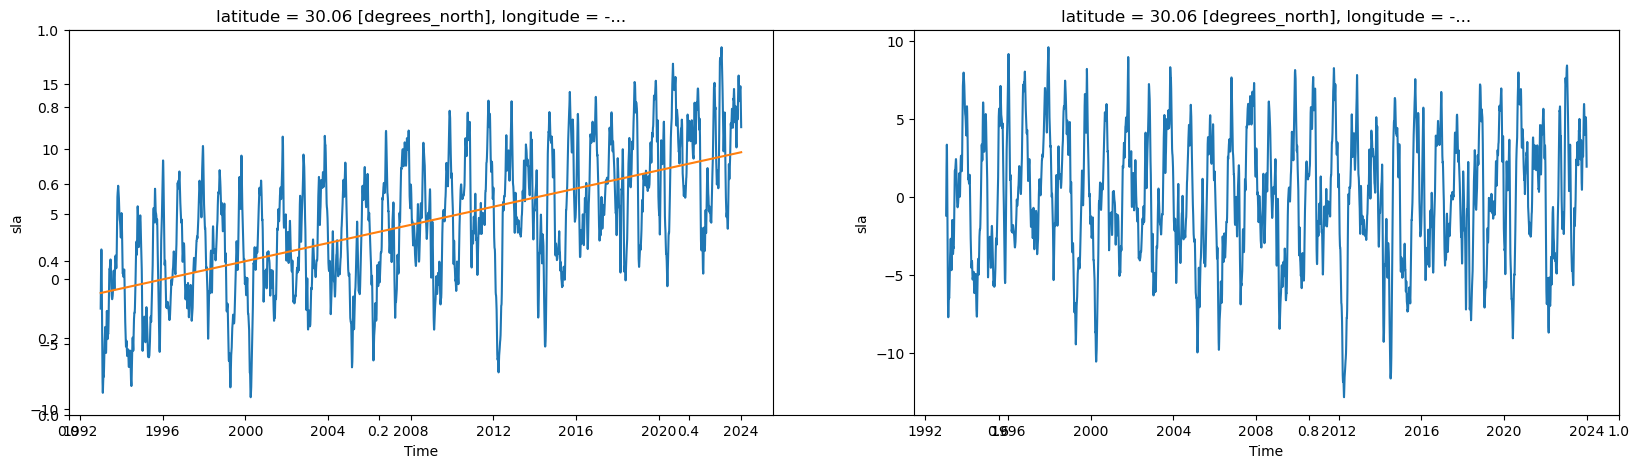

In [31]:
#Se comprueba que si se eliminó bien la tendencia en unas coordenadas ejemplo.
fig, ax = plt.subplots(figsize=(20,5))

plt.subplot(1, 2, 1)
atl.sla.sel(latitude=30, longitude=345-360, method='nearest').plot()
(atl.sla.sel(latitude=30, longitude=345-360, method='nearest') - atl_dt.sel(latitude=30, longitude=345-360, 
                                                                            method='nearest')).plot()

plt.subplot(1, 2, 2)
atl_dt.sel(latitude=30, longitude=345-360, method='nearest').plot();

In [37]:
#Función para quitar la climatología y quedarnos con la anomalía.
def rm(x):
    return x - x.mean(dim='time')

atl_dt_month = atl_dt.groupby('time.month').apply(rm)

In [38]:
#Se obtiene el ciclo estacional y se comprueba que está bien haciendo la media de cada mes a mano.
promedio= np.array([])
for id in range(1,13):
   promedio=np.append(promedio, atl_dt.sel(latitude=30, longitude=345-360, method='nearest')[atl_dt.sel(latitude=30, longitude=345-360, method='nearest').time.dt.month==id].mean())

climm =atl_dt.sel(latitude=30, longitude=345-360, method='nearest').groupby('time.month').mean(dim='time')

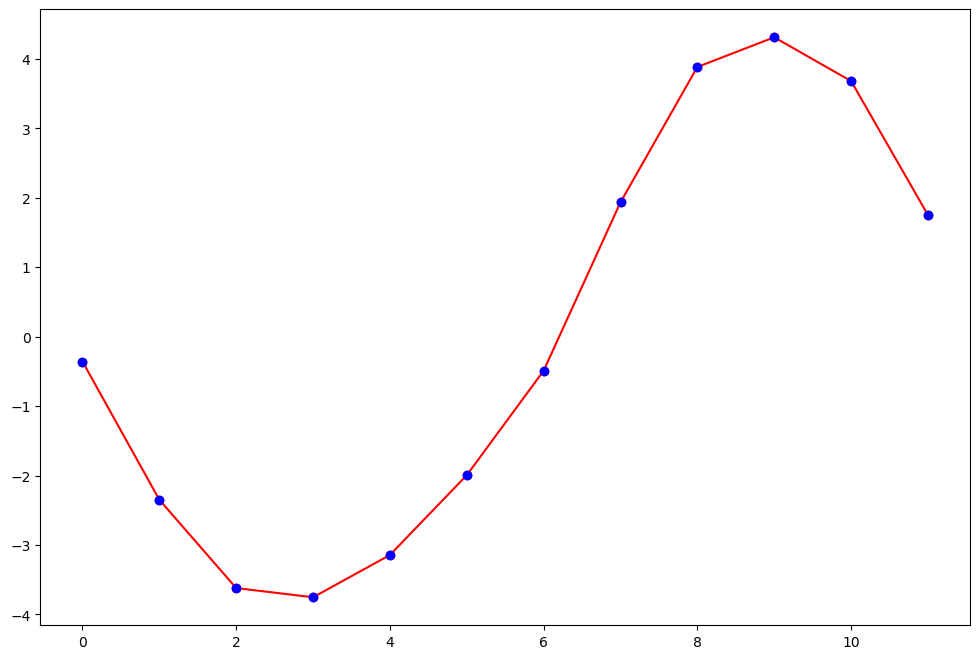

In [39]:
fig , ax = plt.subplots(figsize=(12,8))
ax.plot(promedio,'-ro')
ax.plot(climm,'bo');

#### Figure wih the standart deviation and the areas chooseen to analyse the spectrum

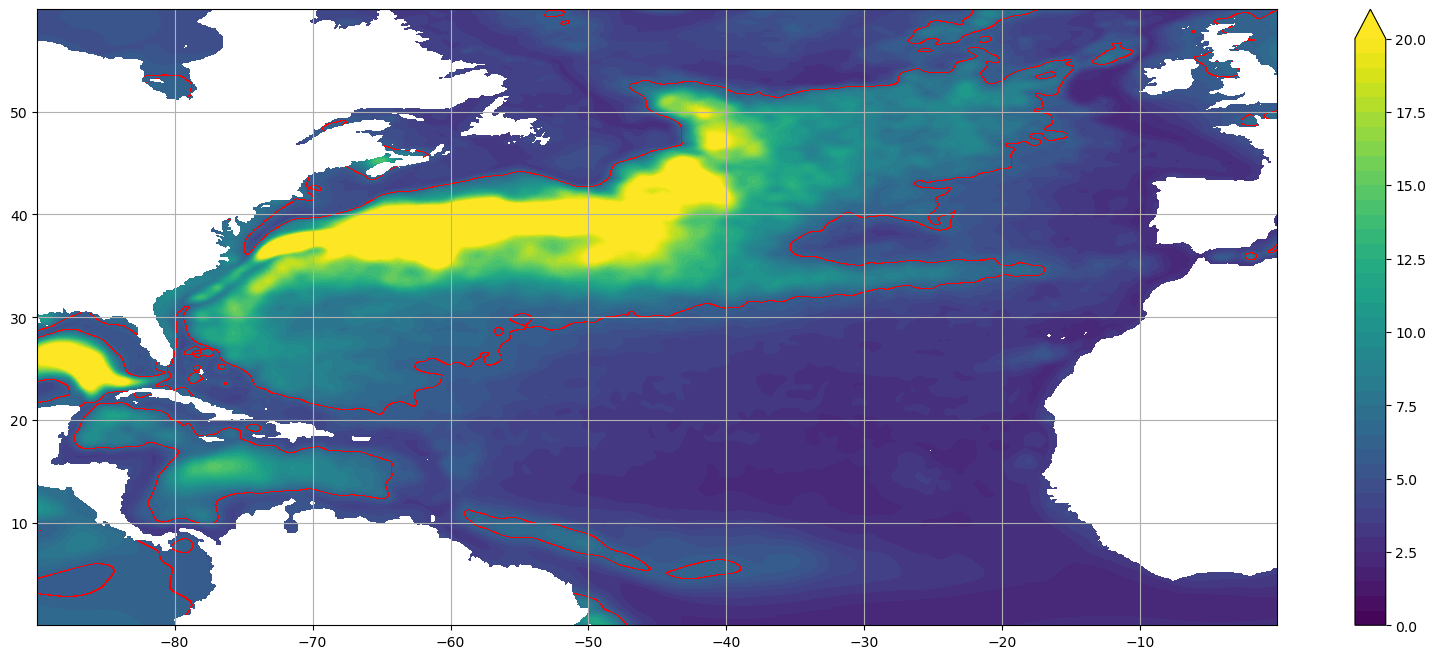

In [15]:
fig, ax = plt.subplots(figsize=(20,8))
levels = np.linspace(0, 0.2*100, 41)

A = ax.contourf(atl_dt_month.longitude, atl_dt_month.latitude, atl_dt_month.std(dim='time'), 
                levels=levels, extend='max')
fig.colorbar(A)

ax.contourf(atl_dt_month.longitude, atl_dt_month.latitude, atl_dt_month.std(dim='time'), 
            levels=[0.0599*100, 0.06*100], colors='red')

ax.xaxis.grid(True, zorder=0)
ax.yaxis.grid(True, zorder=0)

#### Defining the aras

In [48]:
#Area with small variance
ad_lat = atl_dt_month.latitude.loc[10.5:26.5]
ad_lon = atl_dt_month.longitude.loc[318-360:331-360]
ad = atl_dt_month.sel(latitude=ad_lat, longitude=ad_lon)
adp = atl_dt.sel(latitude=ad_lat, longitude=ad_lon)

In [49]:
#Se definen las 10 zonas, con climatología y sin ella.

a1_lat = atl_dt_month.latitude.loc[32:37]
a1_lon = atl_dt_month.longitude.loc[325-360:335-360]
a1 = atl_dt_month.sel(latitude=a1_lat, longitude=a1_lon)
a1p = atl_dt.sel(latitude=a1_lat, longitude=a1_lon)

a2_lat = atl_dt_month.latitude.loc[32:37]
a2_lon = atl_dt_month.longitude.loc[335-360:345-360]
a2 = atl_dt_month.sel(latitude=a2_lat, longitude=a2_lon)
a2p = atl_dt.sel(latitude=a2_lat, longitude=a2_lon)

a3_lat = atl_dt_month.latitude.loc[32:37]
a3_lon = atl_dt_month.longitude.loc[345-360:352-360]
a3 = atl_dt_month.sel(latitude=a3_lat, longitude=a3_lon)
a3p = atl_dt.sel(latitude=a3_lat, longitude=a3_lon)

a4_lat = atl_dt_month.latitude.loc[24:29]
a4_lon = atl_dt_month.longitude.loc[340-360:347-360]
a4 = atl_dt_month.sel(latitude=a4_lat, longitude=a4_lon)
a4p = atl_dt.sel(latitude=a4_lat, longitude=a4_lon)

a5_lat = atl_dt_month.latitude.loc[28:35]
a5_lon = atl_dt_month.longitude.loc[280-360:286-360]
a5 = atl_dt_month.sel(latitude=a5_lat, longitude=a5_lon)
a5p = atl_dt.sel(latitude=a5_lat, longitude=a5_lon)

a6_lat = atl_dt_month.latitude.loc[30:40]
a6_lon = atl_dt_month.longitude.loc[286-360:295-360]
a6 = atl_dt_month.sel(latitude=a6_lat, longitude=a6_lon)
a6p = atl_dt.sel(latitude=a6_lat, longitude=a6_lon)

a7_lat = atl_dt_month.latitude.loc[33:43]
a7_lon = atl_dt_month.longitude.loc[295-360:313-360]
a7 = atl_dt_month.sel(latitude=a7_lat, longitude=a7_lon)
a7p = atl_dt.sel(latitude=a7_lat, longitude=a7_lon)

a8_lat = atl_dt_month.latitude.loc[33:52]
a8_lon = atl_dt_month.longitude.loc[313-360:325-360]
a8 = atl_dt_month.sel(latitude=a8_lat, longitude=a8_lon)
a8p = atl_dt.sel(latitude=a8_lat, longitude=a8_lon)

a9_lat = atl_dt_month.latitude.loc[5:12]
a9_lon = atl_dt_month.longitude.loc[300-360:315-360]
a9 = atl_dt_month.sel(latitude=a9_lat, longitude=a9_lon)
a9p = atl_dt.sel(latitude=a9_lat, longitude=a9_lon)

a10_lat = atl_dt_month.latitude.loc[4:9]
a10_lon = atl_dt_month.longitude.loc[315-360:333-360]
a10 = atl_dt_month.sel(latitude=a10_lat, longitude=a10_lon)
a10p = atl_dt.sel(latitude=a10_lat, longitude=a10_lon)

In [52]:
a1_lon

<xarray.DataArray 'longitude' (longitude: 80)> Size: 320B
array([-34.9375, -34.8125, -34.6875, -34.5625, -34.4375, -34.3125, -34.1875,
       -34.0625, -33.9375, -33.8125, -33.6875, -33.5625, -33.4375, -33.3125,
       -33.1875, -33.0625, -32.9375, -32.8125, -32.6875, -32.5625, -32.4375,
       -32.3125, -32.1875, -32.0625, -31.9375, -31.8125, -31.6875, -31.5625,
       -31.4375, -31.3125, -31.1875, -31.0625, -30.9375, -30.8125, -30.6875,
       -30.5625, -30.4375, -30.3125, -30.1875, -30.0625, -29.9375, -29.8125,
       -29.6875, -29.5625, -29.4375, -29.3125, -29.1875, -29.0625, -28.9375,
       -28.8125, -28.6875, -28.5625, -28.4375, -28.3125, -28.1875, -28.0625,
       -27.9375, -27.8125, -27.6875, -27.5625, -27.4375, -27.3125, -27.1875,
       -27.0625, -26.9375, -26.8125, -26.6875, -26.5625, -26.4375, -26.3125,
       -26.1875, -26.0625, -25.9375, -25.8125, -25.6875, -25.5625, -25.4375,
       -25.3125, -25.1875, -25.0625], dtype=float32)
Coordinates:
  * longitude  (longitude) float32 320B -34.94 -34.81 -34.69 ... -25.19 -25.06
Attributes:
    axis:           X
    long_name:      Longitude
    standard_name:  longitude
    units:          degrees_east
    valid_max:      179.9375
    valid_min:      -179.9375
    bounds:         lon_bnds

IndexError: index 0 is out of bounds for axis 0 with size 0

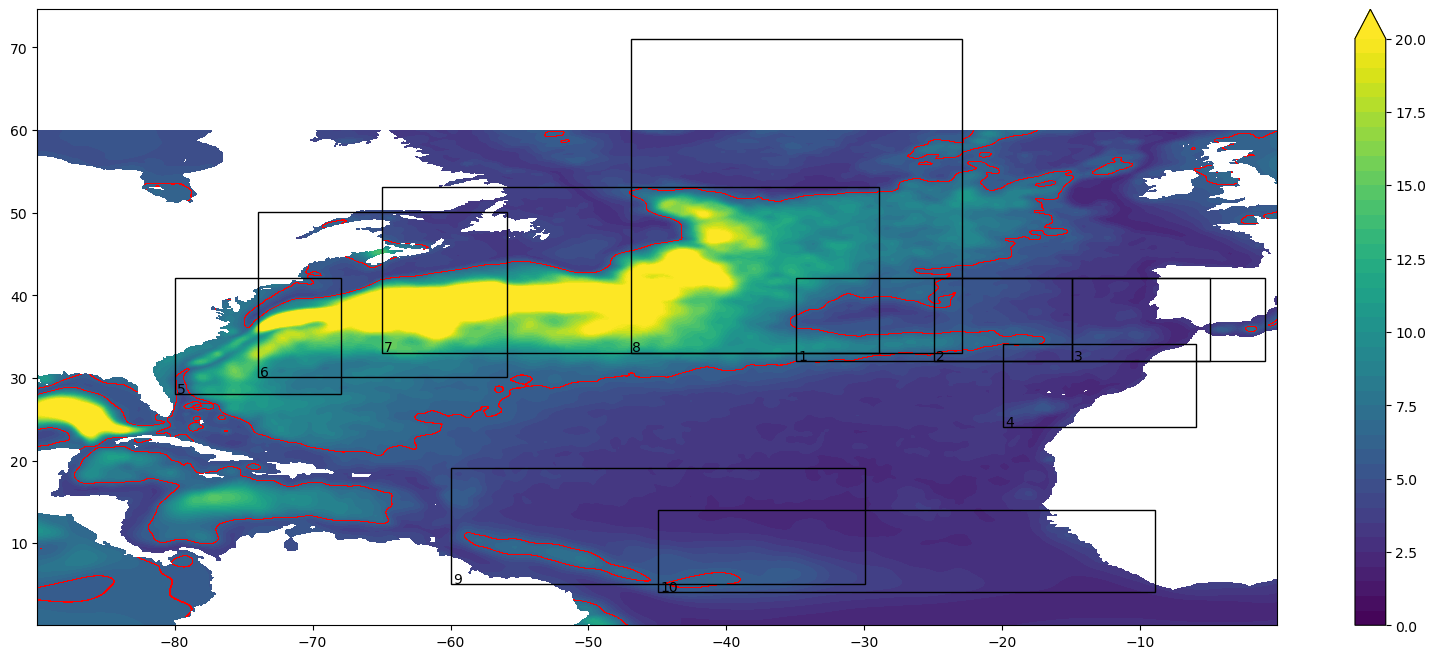

In [30]:
#Representación de las 10 zonas.

fig, ax = plt.subplots(figsize=(20,8))
levels = np.linspace(0, 0.2*100, 41)
A = ax.contourf(atl_dt_month.longitude, atl_dt_month.latitude, atl_dt_month.std(dim='time'), 
                levels=levels, extend='max')
fig.colorbar(A)

ax.contourf(atl_dt_month.longitude, atl_dt_month.latitude, atl_dt_month.std(dim='time'), levels=[0.0599*100, 0.06*100], colors='red')

ax.add_patch(mtp.Rectangle((a1_lon[0],a1_lat[0]), len(a1_lon)*0.25, len(a1_lat)*0.25, edgecolor = 'black', fill=False))
ax.text(a1_lon[1],a1_lat[1], '1')
ax.add_patch(mtp.Rectangle((a2_lon[0],a2_lat[0]), len(a2_lon)*0.25, len(a2_lat)*0.25, edgecolor = 'black', fill=False))
ax.text(a2_lon[1],a2_lat[1], '2')
ax.add_patch(mtp.Rectangle((a3_lon[0],a3_lat[0]), len(a3_lon)*0.25, len(a3_lat)*0.25, edgecolor = 'black', fill=False))
ax.text(a3_lon[1],a3_lat[1], '3')
ax.add_patch(mtp.Rectangle((a4_lon[0],a4_lat[0]), len(a4_lon)*0.25, len(a4_lat)*0.25, edgecolor = 'black', fill=False))
ax.text(a4_lon[1],a4_lat[1], '4')
ax.add_patch(mtp.Rectangle((a5_lon[0],a5_lat[0]), len(a5_lon)*0.25, len(a5_lat)*0.25, edgecolor = 'black', fill=False))
ax.text(a5_lon[1],a5_lat[1], '5')
ax.add_patch(mtp.Rectangle((a6_lon[0],a6_lat[0]), len(a6_lon)*0.25, len(a6_lat)*0.25, edgecolor = 'black', fill=False))
ax.text(a6_lon[1],a6_lat[1], '6')
ax.add_patch(mtp.Rectangle((a7_lon[0],a7_lat[0]), len(a7_lon)*0.25, len(a7_lat)*0.25, edgecolor = 'black', fill=False))
ax.text(a7_lon[1],a7_lat[1], '7')
ax.add_patch(mtp.Rectangle((a8_lon[0],a8_lat[0]), len(a8_lon)*0.25, len(a8_lat)*0.25, edgecolor = 'black', fill=False))
ax.text(a8_lon[1],a8_lat[1], '8')
ax.add_patch(mtp.Rectangle((a9_lon[0],a9_lat[0]), len(a9_lon)*0.25, len(a9_lat)*0.25, edgecolor = 'black', fill=False))
ax.text(a9_lon[1],a9_lat[1], '9')
ax.add_patch(mtp.Rectangle((a10_lon[0],a10_lat[0]), len(a10_lon)*0.25, len(a10_lat)*0.25, edgecolor = 'black', fill=False))
ax.text(a10_lon[1],a10_lat[1], '10')
ax.add_patch(mtp.Rectangle((ad_lon[0],ad_lat[0]), len(ad_lon)*0.25, len(ad_lat)*0.25, edgecolor = 'black', fill=False))
ax.text(ad_lon[1],ad_lat[1], 'Zona Muerta')

ax.set_title('Desviación estándar de la anomalía del Atlántico')
ax.set_xlabel('Longitud (ºE)')
ax.set_ylabel('Latitud (ºN)')


plt.show()

In [53]:
#DataArray del ciclo estacional.
data_clim = atl_dt - atl_dt_month

In [54]:
#Áreas del ciclo estacional.
a1_clim = data_clim.sel(latitude=a1_lat, longitude=a1_lon)
a2_clim = data_clim.sel(latitude=a2_lat, longitude=a2_lon)
a3_clim = data_clim.sel(latitude=a3_lat, longitude=a3_lon)
a4_clim = data_clim.sel(latitude=a4_lat, longitude=a4_lon)
a5_clim = data_clim.sel(latitude=a5_lat, longitude=a5_lon)
a6_clim = data_clim.sel(latitude=a6_lat, longitude=a6_lon)
a7_clim = data_clim.sel(latitude=a7_lat, longitude=a7_lon)
a8_clim = data_clim.sel(latitude=a8_lat, longitude=a8_lon)
a9_clim = data_clim.sel(latitude=a9_lat, longitude=a9_lon)
a10_clim = data_clim.sel(latitude=a10_lat, longitude=a10_lon)

In [55]:
#Análisis espectral de las 10 áreas con las funciones de la universidad de Hawaii.
#Del ciclo.

freqs1_clim, ps1_clim, psd1_clim = spectrum4(a1_clim.values, dt=7)
freqs2_clim, ps2_clim, psd2_clim = spectrum4(a2_clim.values, dt=7)
freqs3_clim, ps3_clim, psd3_clim = spectrum4(a3_clim.values, dt=7)
freqs4_clim, ps4_clim, psd4_clim = spectrum4(a4_clim.values, dt=7)
freqs5_clim, ps5_clim, psd5_clim = spectrum4(a5_clim.values, dt=7)
freqs6_clim, ps6_clim, psd6_clim = spectrum4(a6_clim.values, dt=7)
freqs7_clim, ps7_clim, psd7_clim = spectrum4(a7_clim.values, dt=7)
freqs8_clim, ps8_clim, psd8_clim = spectrum4(a8_clim.values, dt=7)
freqs9_clim, ps9_clim, psd9_clim = spectrum4(a9_clim.values, dt=7)
freqs10_clim, ps10_clim, psd10_clim = spectrum4(a10_clim.values, dt=7)

In [56]:
#Media de todos los puntos de cada área. Nanmean para las áeras que tienen zonas sin datos (porque es tierra).
#Del ciclo.

media1_clim = np.nanmean(np.nanmean(psd1_clim, axis=1), axis=1)
media2_clim = np.nanmean(np.nanmean(psd2_clim, axis=1), axis=1)
media3_clim = np.nanmean(np.nanmean(psd3_clim, axis=1), axis=1)
media4_clim = np.nanmean(np.nanmean(psd4_clim, axis=1), axis=1)
media5_clim = np.nanmean(np.nanmean(psd5_clim, axis=1), axis=1)
media6_clim = np.nanmean(np.nanmean(psd6_clim, axis=1), axis=1)
media7_clim = np.nanmean(np.nanmean(psd7_clim, axis=1), axis=1)
media8_clim = np.nanmean(np.nanmean(psd8_clim, axis=1), axis=1)
media9_clim = np.nanmean(np.nanmean(psd9_clim, axis=1), axis=1)
media10_clim = np.nanmean(np.nanmean(psd10_clim, axis=1), axis=1)

In [57]:
#Sin ciclo.

freqs1, ps1, psd1 = spectrum4(a1.values, dt=int(time_freq))
freqs2, ps2, psd2 = spectrum4(a2.values, dt=int(time_freq))
freqs3, ps3, psd3 = spectrum4(a3.values, dt=int(time_freq))
freqs4, ps4, psd4 = spectrum4(a4.values, dt=int(time_freq))
freqs5, ps5, psd5 = spectrum4(a5.values, dt=int(time_freq))
freqs6, ps6, psd6 = spectrum4(a6.values, dt=int(time_freq))
freqs7, ps7, psd7 = spectrum4(a7.values, dt=int(time_freq))
freqs8, ps8, psd8 = spectrum4(a8.values, dt=int(time_freq))
freqs9, ps9, psd9 = spectrum4(a9.values, dt=int(time_freq))
freqs10, ps10, psd10 = spectrum4(a10.values, dt=int(time_freq))

In [58]:
#De la zona muerta.

freqsd, psd, psdd = spectrum4(ad.values, dt=int(time_freq))
mediad = np.mean(np.mean(psdd, axis=1), axis=1)
freqsdp, psdp, psddp = spectrum4(adp.values, dt=int(time_freq))
mediadp = np.mean(np.mean(psddp, axis=1), axis=1)

In [59]:
#Sin ciclo.

media1 = np.mean(np.mean(psd1, axis=1), axis=1)
media2 = np.mean(np.mean(psd2, axis=1), axis=1)
media3 = np.nanmean(np.nanmean(psd3, axis=1), axis=1)
media4 = np.nanmean(np.nanmean(psd4, axis=1), axis=1)
media5 = np.nanmean(np.nanmean(psd5, axis=1), axis=1)
media6 = np.mean(np.mean(psd6, axis=1), axis=1)
media7 = np.mean(np.mean(psd7, axis=1), axis=1)
media8 = np.mean(np.mean(psd8, axis=1), axis=1)
media9 = np.nanmean(np.nanmean(psd9, axis=1), axis=1)
media10 = np.mean(np.mean(psd10, axis=1), axis=1)

In [60]:
#Con ciclo estacional.

freqs1p, ps1p, psd1p = spectrum4(a1p.values, dt=7)
freqs2p, ps2p, psd2p = spectrum4(a2p.values, dt=7)
freqs3p, ps3p, psd3p = spectrum4(a3p.values, dt=7)
freqs4p, ps4p, psd4p = spectrum4(a4p.values, dt=7)
freqs5p, ps5p, psd5p = spectrum4(a5p.values, dt=7)
freqs6p, ps6p, psd6p = spectrum4(a6p.values, dt=7)
freqs7p, ps7p, psd7p = spectrum4(a7p.values, dt=7)
freqs8p, ps8p, psd8p = spectrum4(a8p.values, dt=7)
freqs9p, ps9p, psd9p = spectrum4(a9p.values, dt=7)
freqs10p, ps10p, psd10p = spectrum4(a10p.values, dt=7)

In [61]:
#Con ciclo estacional.

media1p = np.mean(np.mean(psd1p, axis=1), axis=1)
media2p = np.mean(np.mean(psd2p, axis=1), axis=1)
media3p = np.nanmean(np.nanmean(psd3p, axis=1), axis=1)
media4p = np.nanmean(np.nanmean(psd4p, axis=1), axis=1)
media5p = np.nanmean(np.nanmean(psd5p, axis=1), axis=1)
media6p = np.mean(np.mean(psd6p, axis=1), axis=1)
media7p = np.mean(np.mean(psd7p, axis=1), axis=1)
media8p = np.mean(np.mean(psd8p, axis=1), axis=1)
media9p = np.nanmean(np.nanmean(psd9p, axis=1), axis=1)
media10p = np.mean(np.mean(psd10p, axis=1), axis=1)

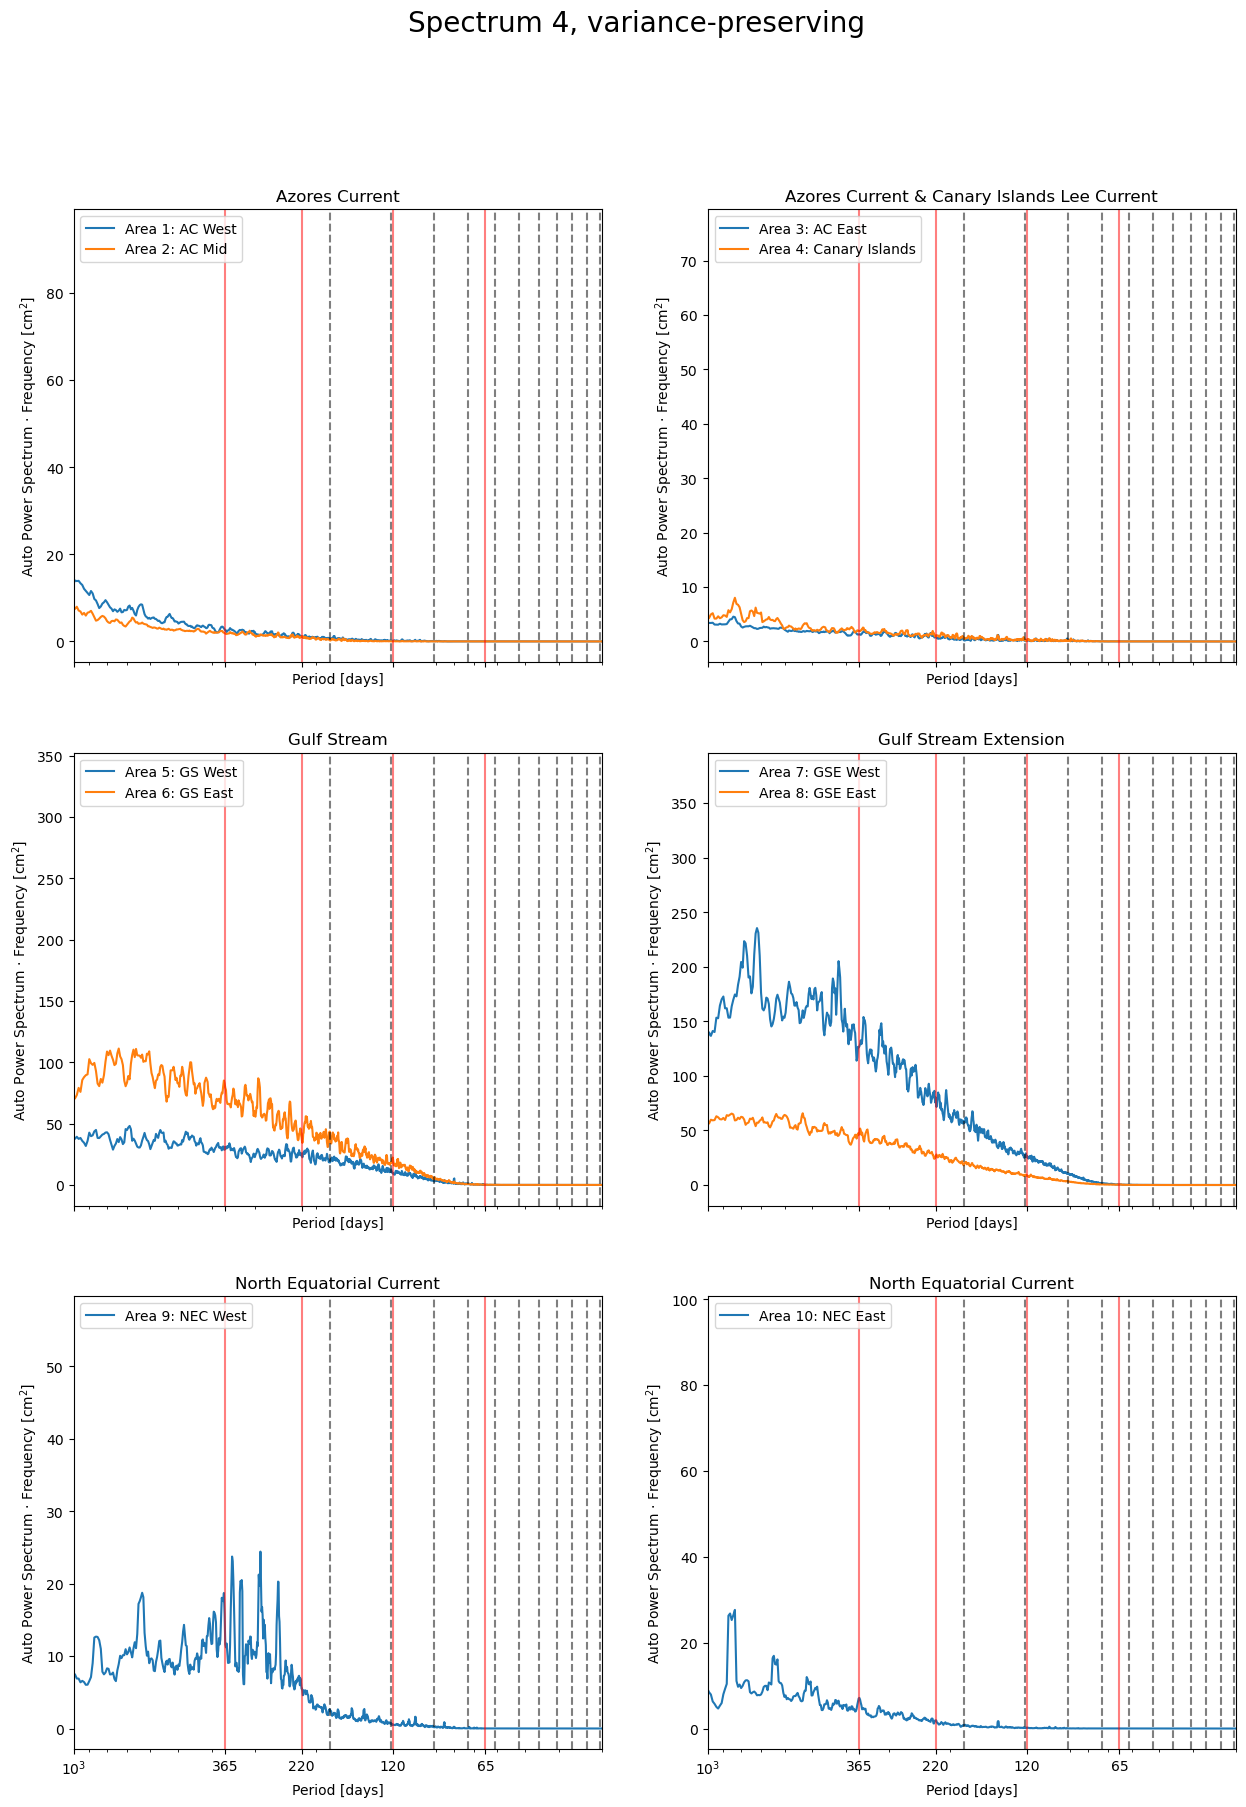

In [62]:
#Utilizando Spectrum 4, con variance-preserving y con el ciclo estacional.
#Las líneas rojas corresponden a 365, 220, 120 y 65 días.
#Las líneas grises a trazos corresponden a los armónicos del ciclo estacional (365/2, 365/3, ... , 365/12).

fig, ax = plt.subplots(3,2 , figsize=(15,20), sharex=True)
plt.xlim(1000, 30)
fig.suptitle('Spectrum 4, variance-preserving', fontsize=20)



ax[0, 0].set_title('Azores Current')
ax[0, 0].semilogx((1/freqs1p)[::-1], media1p[::-1]*freqs1p[::-1])
ax[0, 0].semilogx((1/freqs2p)[::-1], media2p[::-1]*freqs2p[::-1])
ax[0, 0].legend(('Area 1: AC West', 'Area 2: AC Mid'))

ax[0, 1].set_title('Azores Current & Canary Islands Lee Current')
ax[0, 1].semilogx((1/freqs3p)[::-1], media3p[::-1]*freqs3p[::-1])
ax[0, 1].semilogx((1/freqs4p)[::-1], media4p[::-1]*freqs4p[::-1])
ax[0, 1].legend(('Area 3: AC East', 'Area 4: Canary Islands'))

ax[1, 0].set_title('Gulf Stream')
ax[1, 0].semilogx((1/freqs5p)[::-1], media5p[::-1]*freqs5p[::-1])
ax[1, 0].semilogx((1/freqs6p)[::-1], media6p[::-1]*freqs6p[::-1])
ax[1, 0].legend(('Area 5: GS West', 'Area 6: GS East'))

ax[1, 1].set_title('Gulf Stream Extension')
ax[1, 1].semilogx((1/freqs7p)[::-1], media7p[::-1]*freqs7p[::-1])
ax[1, 1].semilogx((1/freqs8p)[::-1], media8p[::-1]*freqs8p[::-1])
ax[1, 1].legend(('Area 7: GSE West', 'Area 8: GSE East'))

ax[2, 0].set_title('North Equatorial Current')
ax[2, 0].semilogx((1/freqs9p)[::-1], media9p[::-1]*freqs9p[::-1])
ax[2, 0].legend(('Area 9: NEC West',))

ax[2, 1].set_title('North Equatorial Current')
ax[2, 1].semilogx((1/freqs10p)[::-1], media10p[::-1]*freqs10p[::-1])
ax[2, 1].legend(('Area 10: NEC East',))

plt.xticks([ 65, 120, 220, 365, 1000], [ '65', '120', '220', '365', '$10^3$'])

for ax in ax.flat:
  ax.axvline(365, ls='-', color='r', alpha=0.5)
  ax.axvline(182.5, ls='--', color='k', alpha=0.5)
  ax.axvline(121.7, ls='--', color='k', alpha=0.5)
  ax.axvline(91.25, ls='--', color='k', alpha=0.5)
  ax.axvline(73, ls='--', color='k', alpha=0.5)
  ax.axvline(60.83, ls='--', color='k', alpha=0.5)
  ax.axvline(52.15, ls='--', color='k', alpha=0.5)
  ax.axvline(45.625, ls='--', color='k', alpha=0.5)
  ax.axvline(40.55, ls='--', color='k', alpha=0.5)
  ax.axvline(36.5, ls='--', color='k', alpha=0.5)
  ax.axvline(33.18, ls='--', color='k', alpha=0.5)
  ax.axvline(30.41, ls='--', color='k', alpha=0.5)
  ax.axvline(28.07, ls='--', color='k', alpha=0.5)
  ax.axvline(220, ls='-', color='r', alpha=0.5)
  ax.axvline(120, ls='-', color='r', alpha=0.5)
  ax.axvline(65, ls='-', color='r', alpha=0.5)
  ax.set(xlabel='Period [days]')
  ax.set(ylabel='Auto Power Spectrum $\cdot$ Frequency [cm$^2$]')
  
plt.show()

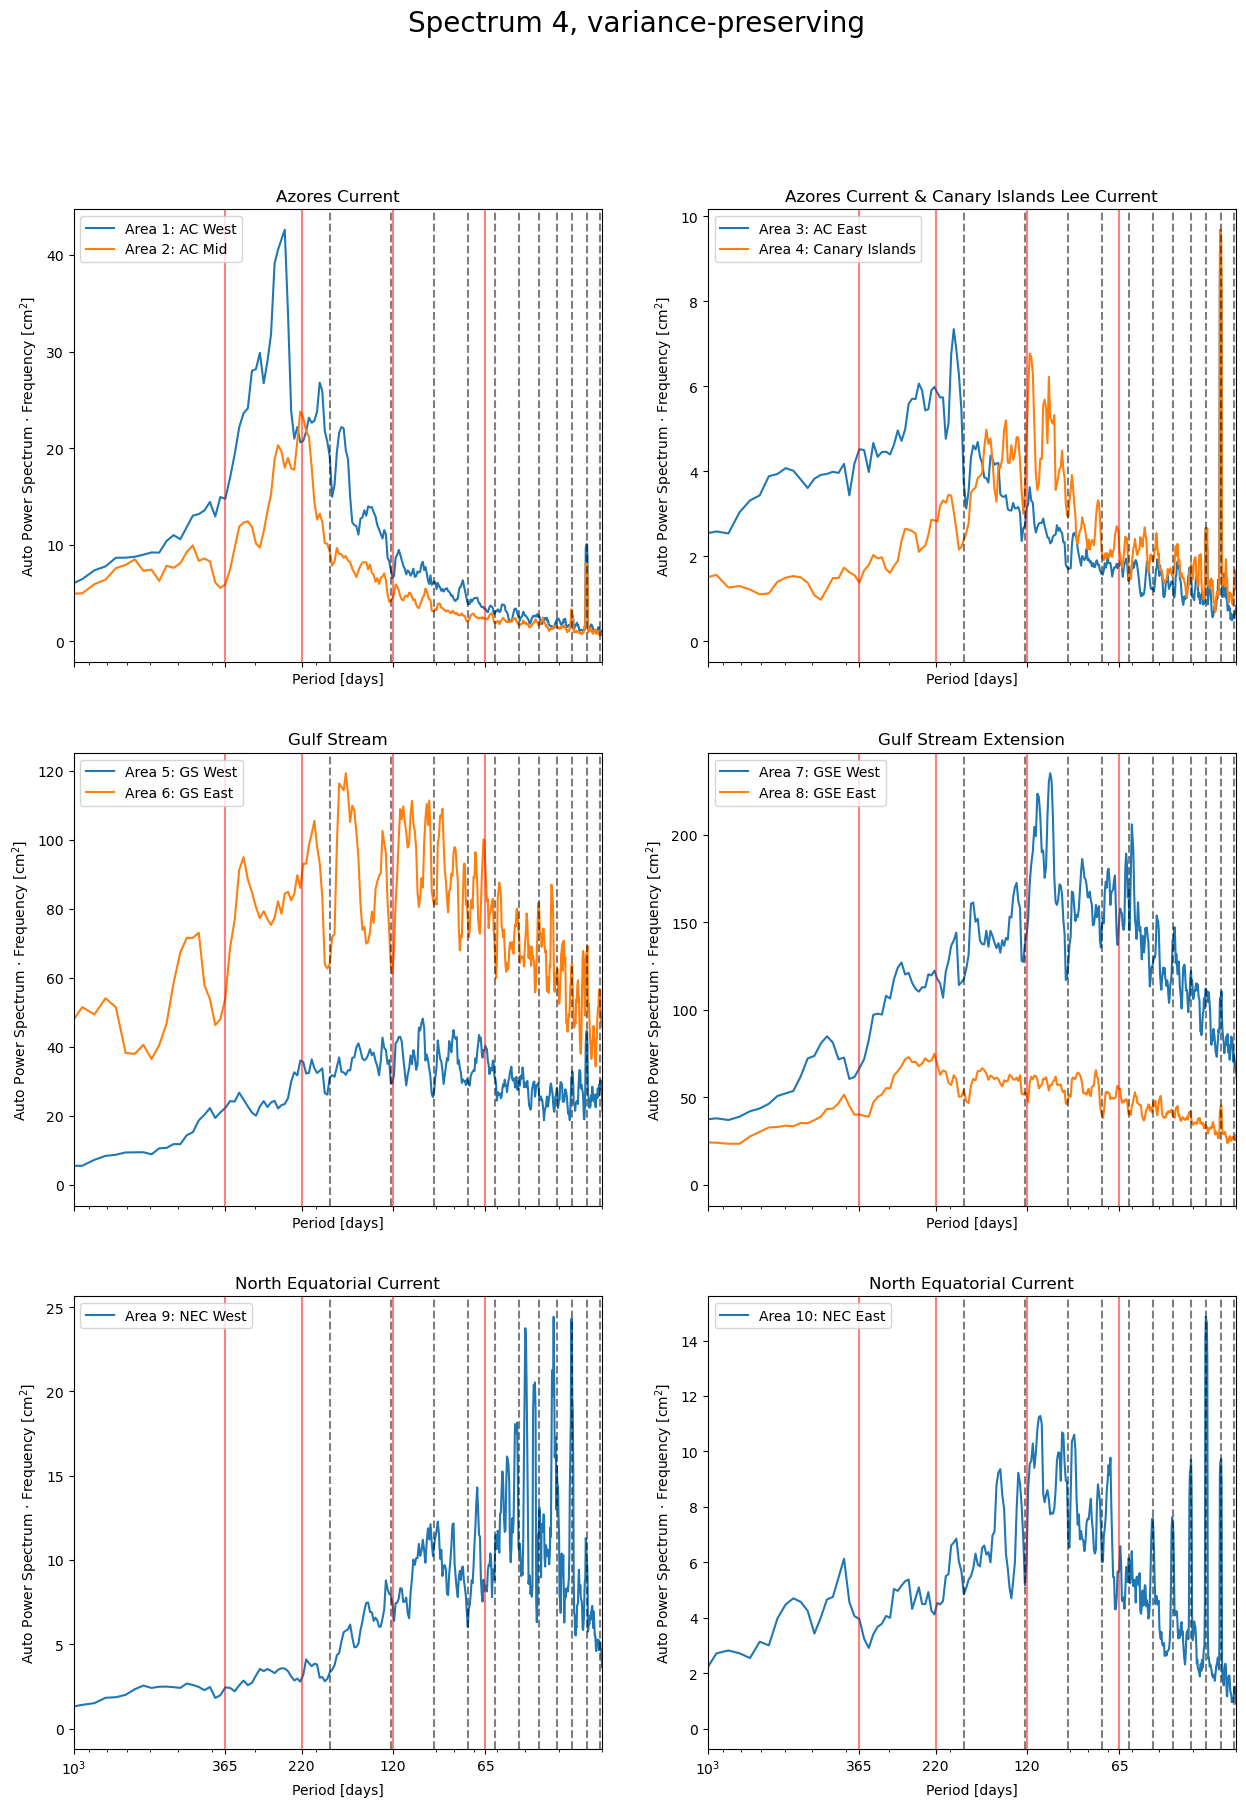

In [63]:
#Lo mismo sin ciclo estacional.

fig, ax = plt.subplots(3,2 , figsize=(15,20), sharex=True)
plt.xlim(1000, 30)
fig.suptitle('Spectrum 4, variance-preserving', fontsize=20)



ax[0, 0].set_title('Azores Current')
ax[0, 0].semilogx((1/freqs1)[::-1], media1[::-1]*freqs1[::-1])
ax[0, 0].semilogx((1/freqs2)[::-1], media2[::-1]*freqs2[::-1])
ax[0, 0].legend(('Area 1: AC West', 'Area 2: AC Mid'))

ax[0, 1].set_title('Azores Current & Canary Islands Lee Current')
ax[0, 1].semilogx((1/freqs3)[::-1], media3[::-1]*freqs3[::-1])
ax[0, 1].semilogx((1/freqs4)[::-1], media4[::-1]*freqs4[::-1])
ax[0, 1].legend(('Area 3: AC East', 'Area 4: Canary Islands'))

ax[1, 0].set_title('Gulf Stream')
ax[1, 0].semilogx((1/freqs5)[::-1], media5[::-1]*freqs5[::-1])
ax[1, 0].semilogx((1/freqs6)[::-1], media6[::-1]*freqs6[::-1])
ax[1, 0].legend(('Area 5: GS West', 'Area 6: GS East'))

ax[1, 1].set_title('Gulf Stream Extension')
ax[1, 1].semilogx((1/freqs7)[::-1], media7[::-1]*freqs7[::-1])
ax[1, 1].semilogx((1/freqs8)[::-1], media8[::-1]*freqs8[::-1])
ax[1, 1].legend(('Area 7: GSE West', 'Area 8: GSE East'))

ax[2, 0].set_title('North Equatorial Current')
ax[2, 0].semilogx((1/freqs9)[::-1], media9[::-1]*freqs9[::-1])
ax[2, 0].legend(('Area 9: NEC West',))

ax[2, 1].set_title('North Equatorial Current')
ax[2, 1].semilogx((1/freqs10)[::-1], media10[::-1]*freqs10[::-1])
ax[2, 1].legend(('Area 10: NEC East',))

plt.xticks([ 65, 120, 220, 365, 1000], [ '65', '120', '220', '365', '$10^3$'])

for ax in ax.flat:
  ax.axvline(365, ls='-', color='r', alpha=0.5)
  ax.axvline(182.5, ls='--', color='k', alpha=0.5)
  ax.axvline(121.7, ls='--', color='k', alpha=0.5)
  ax.axvline(91.25, ls='--', color='k', alpha=0.5)
  ax.axvline(73, ls='--', color='k', alpha=0.5)
  ax.axvline(60.83, ls='--', color='k', alpha=0.5)
  ax.axvline(52.15, ls='--', color='k', alpha=0.5)
  ax.axvline(45.625, ls='--', color='k', alpha=0.5)
  ax.axvline(40.55, ls='--', color='k', alpha=0.5)
  ax.axvline(36.5, ls='--', color='k', alpha=0.5)
  ax.axvline(33.18, ls='--', color='k', alpha=0.5)
  ax.axvline(30.41, ls='--', color='k', alpha=0.5)
  ax.axvline(28.07, ls='--', color='k', alpha=0.5)
  ax.axvline(220, ls='-', color='r', alpha=0.5)
  ax.axvline(120, ls='-', color='r', alpha=0.5)
  ax.axvline(65, ls='-', color='r', alpha=0.5)
  ax.set(xlabel='Period [days]')
  ax.set(ylabel='Auto Power Spectrum $\cdot$ Frequency [cm$^2$]')

plt.show()

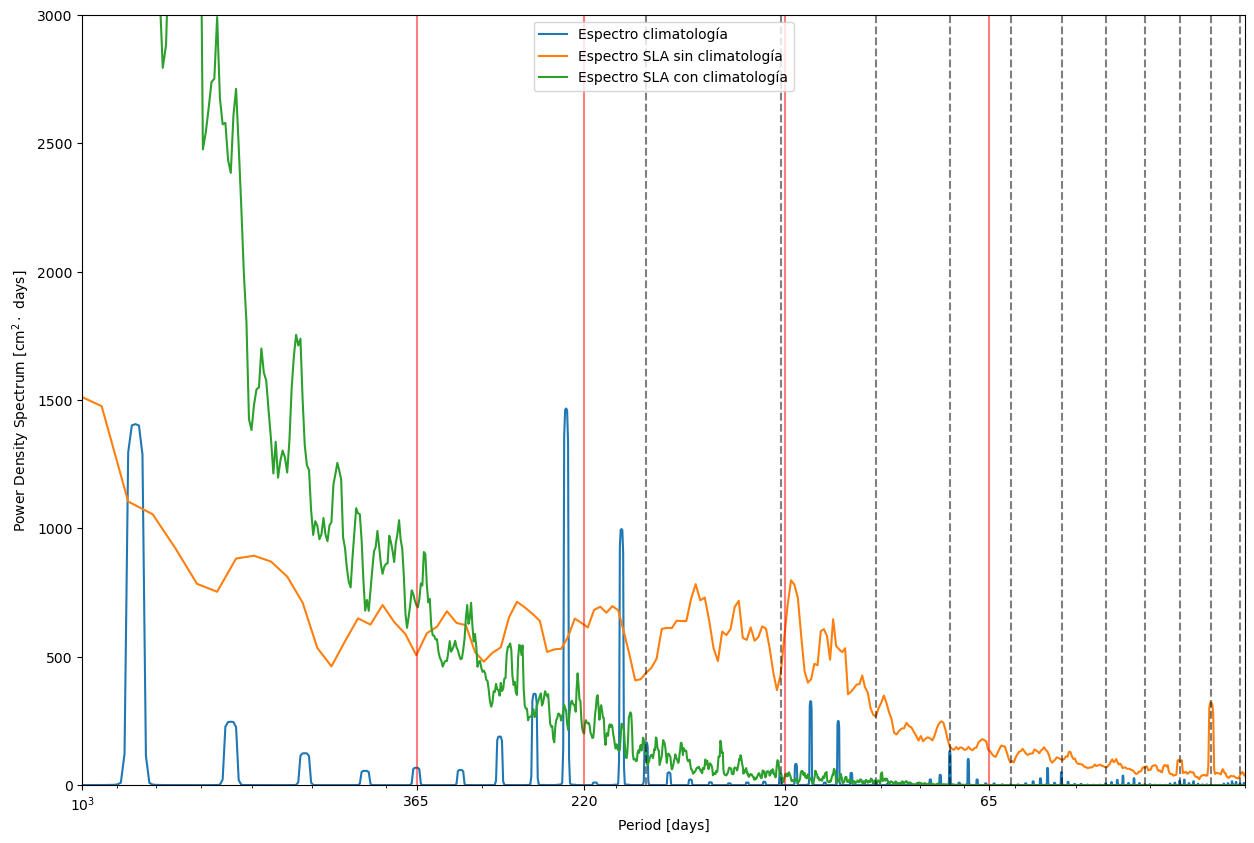

In [64]:
#Comparación de los espectros de la climatología, del SLA con climatología y sin ella del área 4 (Canarias).
#Sin variance-preserving.

fig, ax = plt.subplots(figsize=(15,10))
plt.xlim(1000, 30)
plt.ylim(0, 3000)

ax.semilogx((1/freqs4_clim)[::-1], media4_clim[::-1])
ax.semilogx((1/freqs4)[::-1], media4[::-1])
ax.semilogx((1/freqs4p)[::-1], media4p[::-1])

ax.legend(('Espectro climatología', 'Espectro SLA sin climatología', 'Espectro SLA con climatología'))

plt.xticks([ 65, 120, 220, 365, 1000], [ '65', '120', '220', '365', '$10^3$'])


ax.axvline(365, ls='-', color='r', alpha=0.5)
ax.axvline(182.5, ls='--', color='k', alpha=0.5)
ax.axvline(121.7, ls='--', color='k', alpha=0.5)
ax.axvline(91.25, ls='--', color='k', alpha=0.5)
ax.axvline(73, ls='--', color='k', alpha=0.5)
ax.axvline(60.83, ls='--', color='k', alpha=0.5)
ax.axvline(52.15, ls='--', color='k', alpha=0.5)
ax.axvline(45.625, ls='--', color='k', alpha=0.5)
ax.axvline(40.55, ls='--', color='k', alpha=0.5)
ax.axvline(36.5, ls='--', color='k', alpha=0.5)
ax.axvline(33.18, ls='--', color='k', alpha=0.5)
ax.axvline(30.41, ls='--', color='k', alpha=0.5)
ax.axvline(28.07, ls='--', color='k', alpha=0.5)
ax.axvline(220, ls='-', color='r', alpha=0.5)
ax.axvline(120, ls='-', color='r', alpha=0.5)
ax.axvline(65, ls='-', color='r', alpha=0.5)
ax.set(xlabel='Period [days]')
ax.set(ylabel='Power Density Spectrum [cm$^2\cdot$ days]')



plt.show()

In [29]:
#Integral del PSD entre 65 y 220 sobre todo el Atlántico.

inte = np.zeros([psd_t.shape[1],psd_t.shape[2]])

for i in range(psd_t.shape[1]):
  for j in range(psd_t.shape[2]):
    inte[i,j] = np.trapz(psd_t[44:-552,i,j], freqs_t[44:-552])

In [30]:
#Integral del PSD entre 180 y 300 sobre todo el Atlántico.

intep = np.zeros([psd_t.shape[1],psd_t.shape[2]])

for i in range(psd_t.shape[1]):
  for j in range(psd_t.shape[2]):
    intep[i,j] = np.trapz(psd_t[31:55,i,j], freqs_t[31:55])

/Users/pvb/miniconda3/envs/DataAnalisis/lib/python3.11/site-packages/xarray/core/nputils.py:157: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = getattr(npmodule, name)(values, axis=axis, **kwargs)


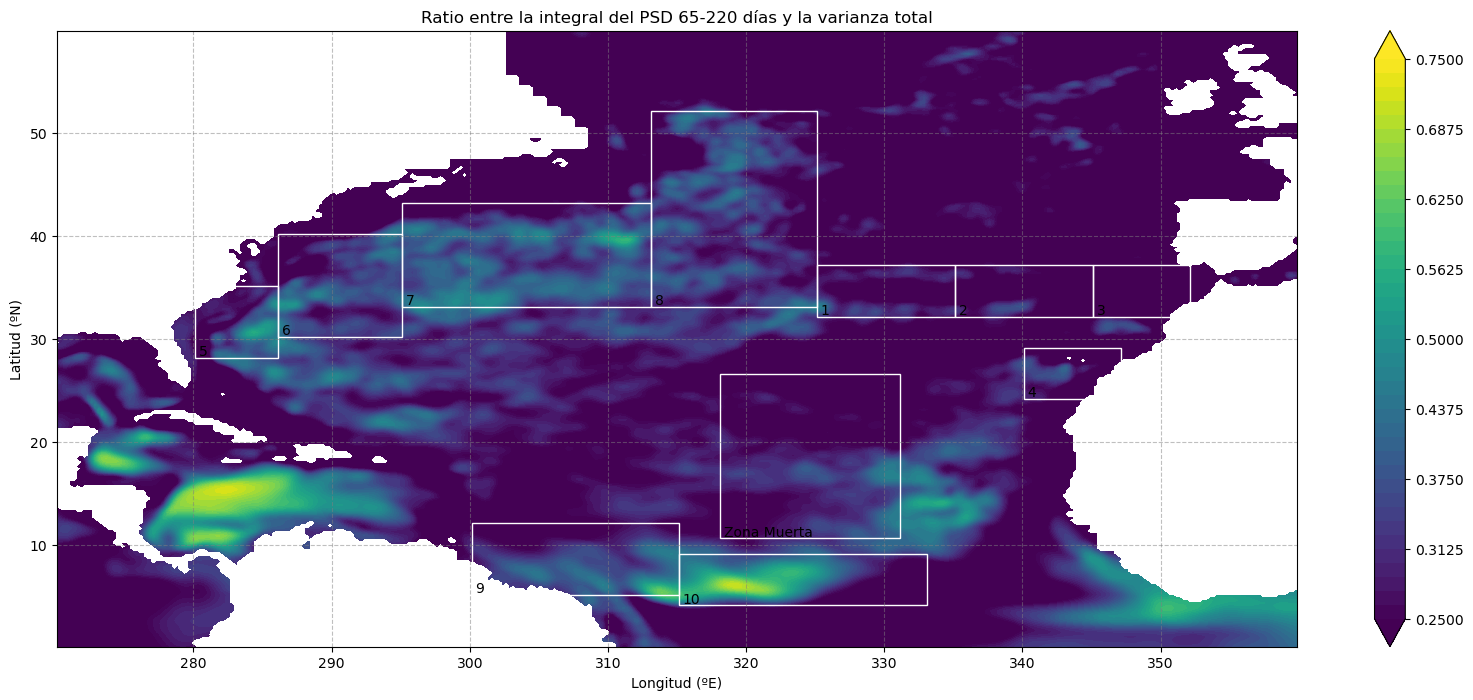

In [31]:
#Representación del ratio 65-220 días y varianza total.

fig, ax = plt.subplots(figsize=(20,8))
levels = np.linspace(0.25, 0.75, 41)
B = ax.contourf(atl_dt_month.longitude, atl_dt_month.latitude, inte / atl_dt.var(dim='time'), 
                levels=levels, extend='both')
fig.colorbar(B)

#ax.contourf(atl_dt_month.longitude, atl_dt_month.latitude, atl_dt_month.std(dim='time'), levels=[0.0599*100, 0.06*100], colors='red')

ax.add_patch(mtp.Rectangle((a1_lon[0],a1_lat[0]), len(a1_lon)*0.25, len(a1_lat)*0.25, edgecolor = 'white', fill=False))
ax.text(a1_lon[1],a1_lat[1], '1')
ax.add_patch(mtp.Rectangle((a2_lon[0],a2_lat[0]), len(a2_lon)*0.25, len(a2_lat)*0.25, edgecolor = 'white', fill=False))
ax.text(a2_lon[1],a2_lat[1], '2')
ax.add_patch(mtp.Rectangle((a3_lon[0],a3_lat[0]), len(a3_lon)*0.25, len(a3_lat)*0.25, edgecolor = 'white', fill=False))
ax.text(a3_lon[1],a3_lat[1], '3')
ax.add_patch(mtp.Rectangle((a4_lon[0],a4_lat[0]), len(a4_lon)*0.25, len(a4_lat)*0.25, edgecolor = 'white', fill=False))
ax.text(a4_lon[1],a4_lat[1], '4')
ax.add_patch(mtp.Rectangle((a5_lon[0],a5_lat[0]), len(a5_lon)*0.25, len(a5_lat)*0.25, edgecolor = 'white', fill=False))
ax.text(a5_lon[1],a5_lat[1], '5')
ax.add_patch(mtp.Rectangle((a6_lon[0],a6_lat[0]), len(a6_lon)*0.25, len(a6_lat)*0.25, edgecolor = 'white', fill=False))
ax.text(a6_lon[1],a6_lat[1], '6')
ax.add_patch(mtp.Rectangle((a7_lon[0],a7_lat[0]), len(a7_lon)*0.25, len(a7_lat)*0.25, edgecolor = 'white', fill=False))
ax.text(a7_lon[1],a7_lat[1], '7')
ax.add_patch(mtp.Rectangle((a8_lon[0],a8_lat[0]), len(a8_lon)*0.25, len(a8_lat)*0.25, edgecolor = 'white', fill=False))
ax.text(a8_lon[1],a8_lat[1], '8')
ax.add_patch(mtp.Rectangle((a9_lon[0],a9_lat[0]), len(a9_lon)*0.25, len(a9_lat)*0.25, edgecolor = 'white', fill=False))
ax.text(a9_lon[1],a9_lat[1], '9')
ax.add_patch(mtp.Rectangle((a10_lon[0],a10_lat[0]), len(a10_lon)*0.25, len(a10_lat)*0.25, edgecolor = 'white', fill=False))
ax.text(a10_lon[1],a10_lat[1], '10')
ax.add_patch(mtp.Rectangle((ad_lon[0],ad_lat[0]), len(ad_lon)*0.25, len(ad_lat)*0.25, edgecolor = 'white', fill=False))
ax.text(ad_lon[1],ad_lat[1], 'Zona Muerta')

ax.set_title('Ratio entre la integral del PSD 65-220 días y la varianza total')
ax.set_xlabel('Longitud (ºE)')
ax.set_ylabel('Latitud (ºN)')

ax.xaxis.grid(True, zorder=0, color='grey', linestyle='--', alpha=0.5)
ax.yaxis.grid(True, zorder=0, color='grey', linestyle='--', alpha=0.5)

plt.show()

/Users/pvb/miniconda3/envs/DataAnalisis/lib/python3.11/site-packages/xarray/core/nputils.py:157: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = getattr(npmodule, name)(values, axis=axis, **kwargs)


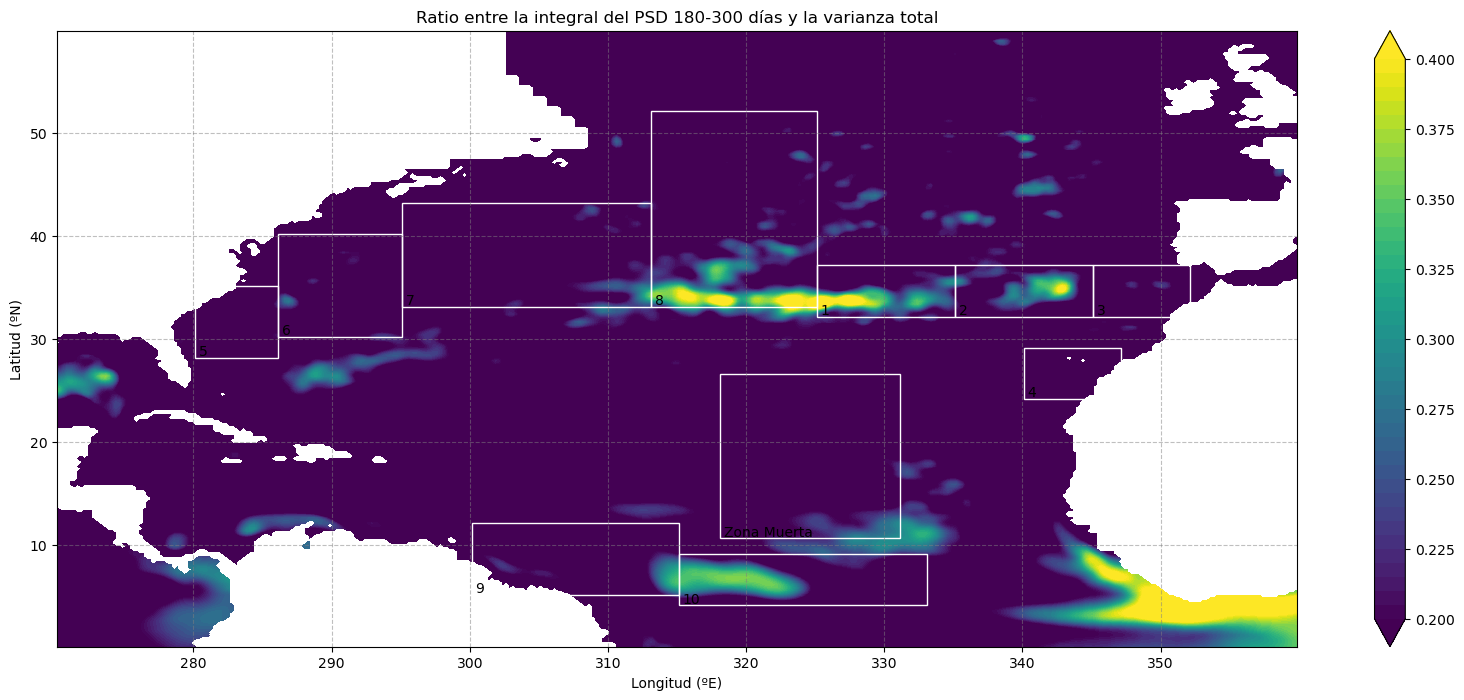

In [32]:
#Representación del ratio 180-300 días y varianza total.

fig, ax = plt.subplots(figsize=(20,8))
levels = np.linspace(0.2, 0.4, 41)
B = ax.contourf(atl_dt_month.longitude, atl_dt_month.latitude, intep / atl_dt.var(dim='time'), 
                levels=levels, extend='both')
fig.colorbar(B)

#ax.contourf(atl_dt_month.longitude, atl_dt_month.latitude, atl_dt_month.std(dim='time'), levels=[0.0599*100, 0.06*100], colors='red')

ax.add_patch(mtp.Rectangle((a1_lon[0],a1_lat[0]), len(a1_lon)*0.25, len(a1_lat)*0.25, edgecolor = 'white', fill=False))
ax.text(a1_lon[1],a1_lat[1], '1')
ax.add_patch(mtp.Rectangle((a2_lon[0],a2_lat[0]), len(a2_lon)*0.25, len(a2_lat)*0.25, edgecolor = 'white', fill=False))
ax.text(a2_lon[1],a2_lat[1], '2')
ax.add_patch(mtp.Rectangle((a3_lon[0],a3_lat[0]), len(a3_lon)*0.25, len(a3_lat)*0.25, edgecolor = 'white', fill=False))
ax.text(a3_lon[1],a3_lat[1], '3')
ax.add_patch(mtp.Rectangle((a4_lon[0],a4_lat[0]), len(a4_lon)*0.25, len(a4_lat)*0.25, edgecolor = 'white', fill=False))
ax.text(a4_lon[1],a4_lat[1], '4')
ax.add_patch(mtp.Rectangle((a5_lon[0],a5_lat[0]), len(a5_lon)*0.25, len(a5_lat)*0.25, edgecolor = 'white', fill=False))
ax.text(a5_lon[1],a5_lat[1], '5')
ax.add_patch(mtp.Rectangle((a6_lon[0],a6_lat[0]), len(a6_lon)*0.25, len(a6_lat)*0.25, edgecolor = 'white', fill=False))
ax.text(a6_lon[1],a6_lat[1], '6')
ax.add_patch(mtp.Rectangle((a7_lon[0],a7_lat[0]), len(a7_lon)*0.25, len(a7_lat)*0.25, edgecolor = 'white', fill=False))
ax.text(a7_lon[1],a7_lat[1], '7')
ax.add_patch(mtp.Rectangle((a8_lon[0],a8_lat[0]), len(a8_lon)*0.25, len(a8_lat)*0.25, edgecolor = 'white', fill=False))
ax.text(a8_lon[1],a8_lat[1], '8')
ax.add_patch(mtp.Rectangle((a9_lon[0],a9_lat[0]), len(a9_lon)*0.25, len(a9_lat)*0.25, edgecolor = 'white', fill=False))
ax.text(a9_lon[1],a9_lat[1], '9')
ax.add_patch(mtp.Rectangle((a10_lon[0],a10_lat[0]), len(a10_lon)*0.25, len(a10_lat)*0.25, edgecolor = 'white', fill=False))
ax.text(a10_lon[1],a10_lat[1], '10')
ax.add_patch(mtp.Rectangle((ad_lon[0],ad_lat[0]), len(ad_lon)*0.25, len(ad_lat)*0.25, edgecolor = 'white', fill=False))
ax.text(ad_lon[1],ad_lat[1], 'Zona Muerta')

ax.set_title('Ratio entre la integral del PSD 180-300 días y la varianza total')
ax.set_xlabel('Longitud (ºE)')
ax.set_ylabel('Latitud (ºN)')

ax.xaxis.grid(True, zorder=0, color='grey', linestyle='--', alpha=0.5)
ax.yaxis.grid(True, zorder=0, color='grey', linestyle='--', alpha=0.5)

#ax.set_global()
#ax.coastlines()
#ax.add_feature(cartopy.feature.LAND.with_scale('110m'))

plt.show()

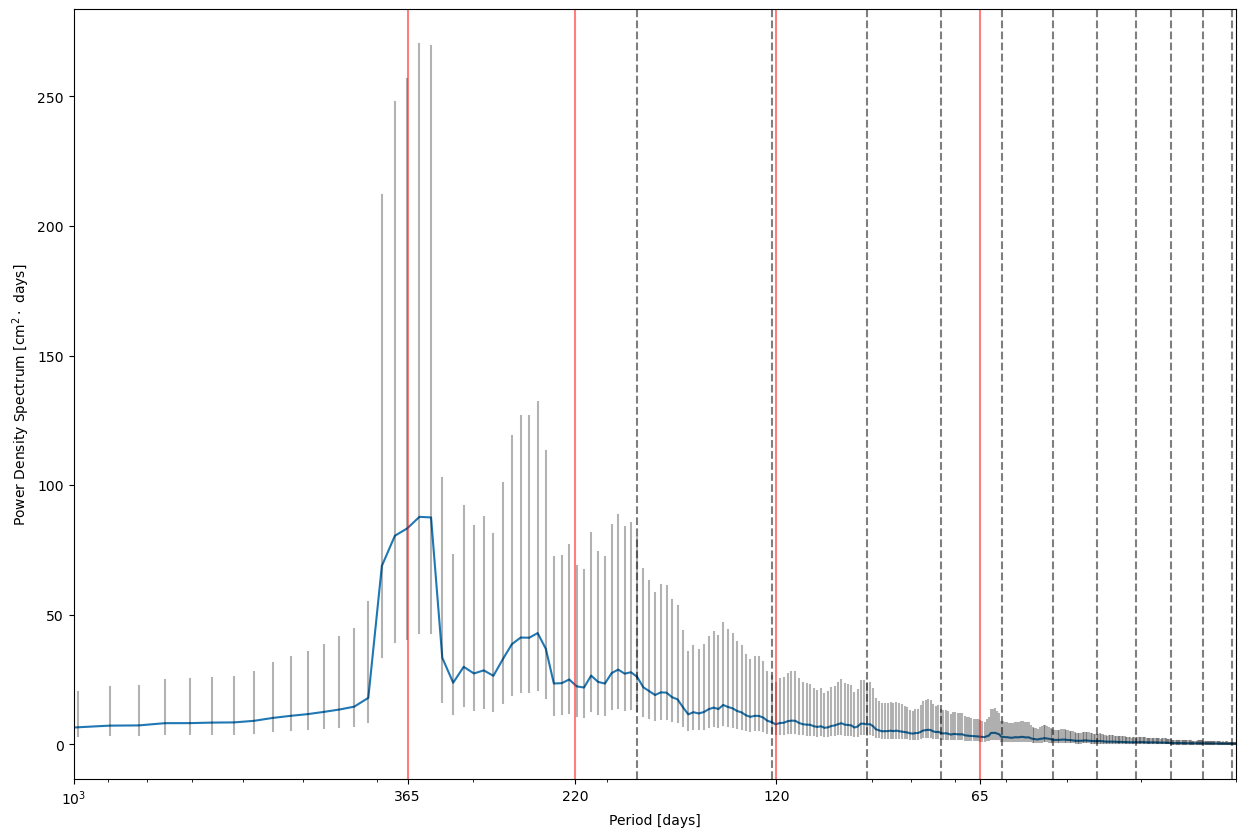

In [33]:
fig, ax = plt.subplots(figsize=(15, 10))
plt.xlim(1000, 30)

ax.semilogx((1/freqs1p)[::-1], media1p[::-1]*freqs1p[::-1])

df = 10 # DOF for 5-point boxcar smoother

# location of confidence limit bar
#conf_x = 150
#conf_y0 = 20


conf_x = (1/freqs1p)[::-1]
conf_y0 = media1p[::-1]*freqs1p[::-1]
#conf = np.zeros([len(media1p[::-1]*freqs1p[::-1]), 2])
conf = np.array([0,0])

for i in range(len(media1p[::-1]*freqs1p[::-1])):
  a = conf_y0[i] * df / ss.chi2.ppf([0.025, 0.975], df)
  conf = np.vstack((conf, a))

np.delete(conf,0,axis=0)

for i in range(1,len((1/freqs1p)[::-1])):
  ax.plot([conf_x[i-1], conf_x[i-1]], conf[i,:], color='k', lw=1.5, alpha=0.3)

plt.xticks([ 65, 120, 220, 365, 1000], [ '65', '120', '220', '365', '$10^3$'])


ax.axvline(365, ls='-', color='r', alpha=0.5)
ax.axvline(182.5, ls='--', color='k', alpha=0.5)
ax.axvline(121.7, ls='--', color='k', alpha=0.5)
ax.axvline(91.25, ls='--', color='k', alpha=0.5)
ax.axvline(73, ls='--', color='k', alpha=0.5)
ax.axvline(60.83, ls='--', color='k', alpha=0.5)
ax.axvline(52.15, ls='--', color='k', alpha=0.5)
ax.axvline(45.625, ls='--', color='k', alpha=0.5)
ax.axvline(40.55, ls='--', color='k', alpha=0.5)
ax.axvline(36.5, ls='--', color='k', alpha=0.5)
ax.axvline(33.18, ls='--', color='k', alpha=0.5)
ax.axvline(30.41, ls='--', color='k', alpha=0.5)
ax.axvline(28.07, ls='--', color='k', alpha=0.5)
ax.axvline(220, ls='-', color='r', alpha=0.5)
ax.axvline(120, ls='-', color='r', alpha=0.5)
ax.axvline(65, ls='-', color='r', alpha=0.5)
ax.set(xlabel='Period [days]')
ax.set(ylabel='Power Density Spectrum [cm$^2\cdot$ days]')

plt.show()

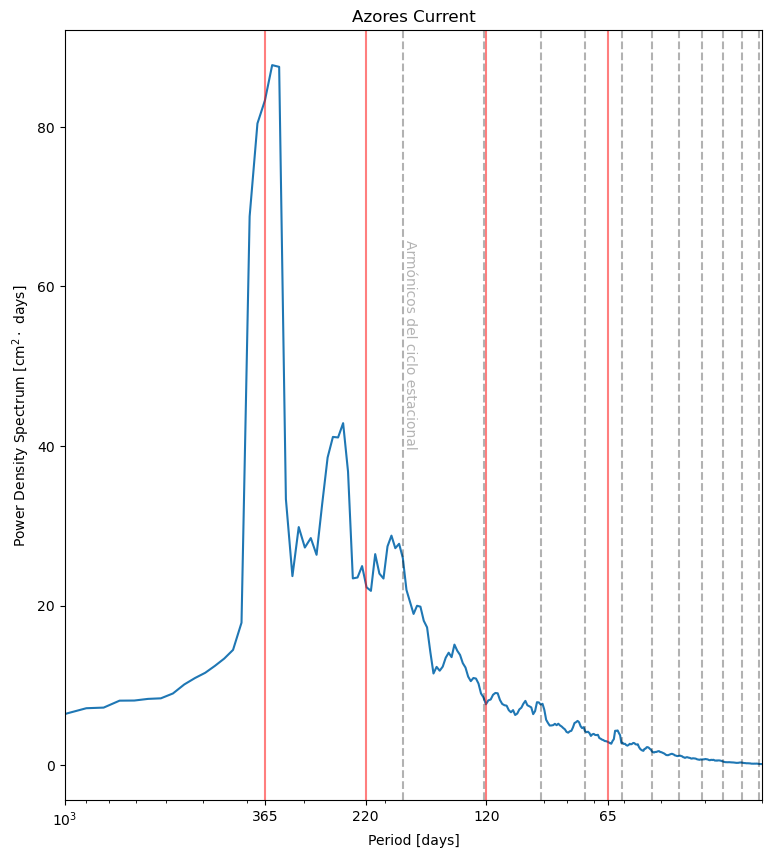

In [34]:
fig, ax = plt.subplots(figsize=(9, 10))
plt.xlim(1000, 30)

ax.semilogx((1/freqs1p)[::-1], media1p[::-1]*freqs1p[::-1])

plt.xticks([ 65, 120, 220, 365, 1000], [ '65', '120', '220', '365', '$10^3$'])
ax.set_title('Azores Current')


ax.axvline(365, ls='-', color='r', alpha=0.5)
ax.axvline(182.5, ls='--', color='k', alpha=0.3)
ax.axvline(121.7, ls='--', color='k', alpha=0.3)
ax.axvline(91.25, ls='--', color='k', alpha=0.3)
ax.axvline(73, ls='--', color='k', alpha=0.3)
ax.axvline(60.83, ls='--', color='k', alpha=0.3)
ax.axvline(52.15, ls='--', color='k', alpha=0.3)
ax.axvline(45.625, ls='--', color='k', alpha=0.3)
ax.axvline(40.55, ls='--', color='k', alpha=0.3)
ax.axvline(36.5, ls='--', color='k', alpha=0.3)
ax.axvline(33.18, ls='--', color='k', alpha=0.3)
ax.axvline(30.41, ls='--', color='k', alpha=0.3)
ax.axvline(28.07, ls='--', color='k', alpha=0.3)
ax.axvline(220, ls='-', color='r', alpha=0.5)
ax.axvline(120, ls='-', color='r', alpha=0.5)
ax.axvline(65, ls='-', color='r', alpha=0.5)
ax.set(xlabel='Period [days]')
ax.set(ylabel='Power Density Spectrum [cm$^2\cdot$ days]')

ax.text(182.4, 40,'Armónicos del ciclo estacional',rotation=270, alpha=0.3)

plt.show()